## Imports And Library Loading

In [1]:
import os
import json
import datetime
from collections import defaultdict, OrderedDict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms

import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve, average_precision_score
)


c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Checkpoint Manager

In [2]:
# ===== External Checkpoint Manager (stores outside experiments/) =====
import os, json, glob, torch, tempfile, shutil
from pathlib import Path

class CheckpointManager:
    """
    Stores all checkpoints under: C:/Users/Shohan/Desktop/DeepFakeImg/DeepFakeDensenet/checkpoints/<exp_name>/
      checkpoints/
        epoch_0001.ckpt
        epoch_0002.ckpt
        ...
      best_model.pth
      last_model.pth
    where:
      - root_dir is hardcoded to "C:/Users/Shohan/Desktop/DeepFakeImg/DeepFakeDensenet/checkpoints"
      - exp_name is derived from cfg.exp_name or basename(cfg.exp_dir)
    """
    def __init__(self, cfg, update_cfg_paths=True, mirror_into_experiments=False):
        # Hardcoded root directory as requested
        self.root_dir = Path("C:/Users/Shohan/Desktop/DeepFakeImg/DeepFakeDensenet/checkpoints")
        self.cfg = cfg
        self.exp_name = getattr(cfg, "exp_name", None) or Path(cfg.exp_dir).name

        # external checkpoint directory
        self.ckpt_root = self.root_dir / self.exp_name
        self.ckpt_dir = self.ckpt_root / "checkpoints"
        self.ckpt_root.mkdir(parents=True, exist_ok=True)
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

        # external best/last
        self.best_path_ext = self.ckpt_root / "best_model.pth"
        self.last_path_ext = self.ckpt_root / "last_model.pth"

        # whether to also copy best/last into experiments (optional)
        self.mirror_into_experiments = mirror_into_experiments

        # optionally rewrite cfg paths so your training loop uses the external ones
        if update_cfg_paths:
            self._rewrite_cfg_paths_to_external()

        # ensure experiments dir exists for reports/plots/history
        Path(cfg.exp_dir).mkdir(parents=True, exist_ok=True)

    # ---------- internals ----------
    def _rewrite_cfg_paths_to_external(self):
        self.cfg.best_model_path = str(self.best_path_ext)
        self.cfg.last_model_path = str(self.last_path_ext)
        # training_history.json, plots, reports remain in experiments/<exp_name> (unchanged)

    def _atomic_save(self, obj, dst_path: Path):
        tmp_fd, tmp_path = tempfile.mkstemp(dir=str(dst_path.parent), prefix=".tmp_", suffix=".pt")
        os.close(tmp_fd)
        torch.save(obj, tmp_path)
        os.replace(tmp_path, dst_path)  # atomic on same filesystem

    def _maybe_mirror(self, src_path: Path, dst_path: Path):
        if not self.mirror_into_experiments:
            return
        dst_path = Path(dst_path)
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src_path, dst_path)

    # ---------- Save ----------
    def save_epoch(self, epoch, model, optimizer, scheduler, best_metrics):
        path = self.ckpt_dir / f"epoch_{epoch:04d}.ckpt"
        payload = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": getattr(scheduler, "state_dict", lambda: {})(),
            "best_metrics": best_metrics
        }
        self._atomic_save(payload, path)
        return str(path)

    def save_best(self, epoch, model, optimizer, scheduler, best_metrics):
        payload = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": getattr(scheduler, "state_dict", lambda: {})(),
            "best_metrics": best_metrics
        }
        self._atomic_save(payload, self.best_path_ext)
        # optional mirror inside experiments dir
        self._maybe_mirror(self.best_path_ext, Path(self.cfg.exp_dir) / "best_model.pth")
        return str(self.best_path_ext)

    def save_last(self, epoch, model, optimizer, scheduler, best_metrics):
        payload = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": getattr(scheduler, "state_dict", lambda: {})(),
            "best_metrics": best_metrics
        }
        self._atomic_save(payload, self.last_path_ext)
        # optional mirror inside experiments dir
        self._maybe_mirror(self.last_path_ext, Path(self.cfg.exp_dir) / "last_model.pth")
        return str(self.last_path_ext)

    # ---------- Load ----------
    def _list_epoch_ckpts(self):
        return sorted(glob.glob(str(self.ckpt_dir / "epoch_*.ckpt")))

    def latest_epoch_ckpt(self):
        files = self._list_epoch_ckpts()
        return files[-1] if files else None

    def load_checkpoint(self, path, model, optimizer=None, scheduler=None, map_location=None):
        ckpt = torch.load(path, map_location=map_location)
        model.load_state_dict(ckpt["model_state_dict"])
        if optimizer is not None and "optimizer_state_dict" in ckpt:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if scheduler is not None and "scheduler_state_dict" in ckpt and ckpt["scheduler_state_dict"]:
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        best_metrics = ckpt.get("best_metrics", {'auc':0.0, 'epoch':0, 'val_loss':float('inf')})
        start_epoch = ckpt.get("epoch", 0)  # last finished epoch
        return start_epoch, best_metrics
    
    # New method to find and load the latest checkpoint
    def resume(self, model, optimizer, scheduler, map_location=None):
        latest_ckpt_path = self.latest_epoch_ckpt()
        if latest_ckpt_path:
            print(f"Resuming from checkpoint: {latest_ckpt_path}")
            start_epoch, best_metrics = self.load_checkpoint(latest_ckpt_path, model, optimizer, scheduler, map_location)
            return start_epoch + 1, best_metrics
        else:
            print("No checkpoint found. Starting from scratch.")
            return 0, {'auc':0.0, 'epoch':0, 'val_loss':float('inf')}

    # ---------- History (still inside experiments/) ----------
    def load_history(self):
        p = Path(self.cfg.training_history_json)
        if p.exists():
            try:
                return json.loads(p.read_text())
            except Exception:
                return {}
        return {}

    def save_history(self, history):
        p = Path(self.cfg.training_history_json)
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text(json.dumps(history, indent=2))

## Dataset Class And Validation

In [5]:
from torch.utils.data import Dataset

# 2) Dataset class (thin wrapper around ImageFolder)
class ImageDataset(Dataset):
    def __init__(self, dataset_root, transform=None):
        self.data_dir = os.path.abspath(dataset_root)
        self.data = ImageFolder(self.data_dir, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    @property
    def classes(self):
        return self.data.classes

    @property
    def class_to_idx(self):
        return self.data.class_to_idx


## DataSet  Loader Dir

In [6]:
from torchvision.datasets import ImageFolder
import json, os

#Datset ROOT Dir
dataset_root = "dataset"
# Directories
train_data_dir = "dataset/train"
val_data_dir   = "dataset/val"
test_data_dir  = "dataset/test"

# Get mappings
class_to_idx_train = ImageFolder(train_data_dir).class_to_idx
class_to_idx_val   = ImageFolder(val_data_dir).class_to_idx
class_to_idx_test  = ImageFolder(test_data_dir).class_to_idx

# Invert mappings (idx -> class)
target_to_class_train = {v: k for k, v in class_to_idx_train.items()}
target_to_class_val   = {v: k for k, v in class_to_idx_val.items()}
target_to_class_test  = {v: k for k, v in class_to_idx_test.items()}

print("Train mapping:", target_to_class_train)
print("Val   mapping:", target_to_class_val)
print("Test  mapping:", target_to_class_test)

# Ensure consistency
assert class_to_idx_train == class_to_idx_val == class_to_idx_test, "Class mapping differs!"
print("\n✅ Class index mapping consistent across splits.")

# Save to JSON
with open("class_names.json", "w") as f:
    json.dump(class_to_idx_train, f, indent=4)
print("Saved mapping to class_names.json")


# 1) Dataset loading
data_root = "dataset"
train_dataset = ImageDataset(os.path.join(data_root, "train"))
val_dataset   = ImageDataset(os.path.join(data_root, "val"))
test_dataset  = ImageDataset(os.path.join(data_root, "test"))

with open("class_names.json", "w") as f:
    json.dump(train_dataset.class_to_idx, f, indent=4)

print("classes:", train_dataset.classes)
print("sizes:", len(train_dataset), len(val_dataset), len(test_dataset))


Train mapping: {0: 'fake', 1: 'real'}
Val   mapping: {0: 'fake', 1: 'real'}
Test  mapping: {0: 'fake', 1: 'real'}

✅ Class index mapping consistent across splits.
Saved mapping to class_names.json
classes: ['fake', 'real']
sizes: 25696 3212 3213


0


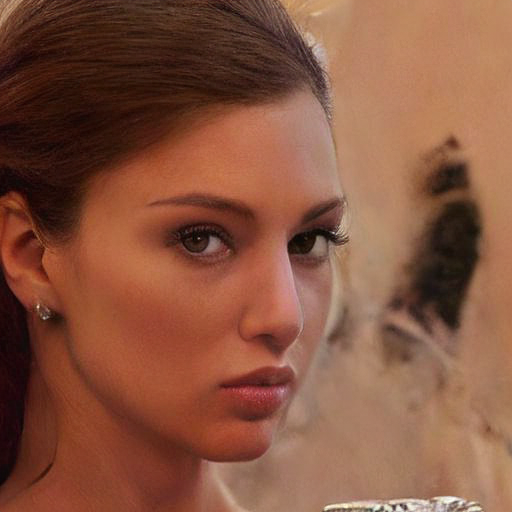

In [7]:
# Test Itration
image, label = test_dataset[300]
print(label)
image

## Dataset Augmentation

In [8]:
import torchvision.transforms as transforms
import torch  # Needed for torch.rand() for dynamic sharpness

# ImageNet stats (used for pretrained CNN backbones like DenseNet, ResNet, etc.)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    # 1. Resizing
    transforms.Resize((256, 256)),

    # 2. Geometric transforms
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomApply([transforms.ElasticTransform(alpha=250.0, sigma=15.0)], p=0.2),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),

    # 3. Photometric / color transforms
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0)),

    # Random sharpness/blur (fixed factor for this transform instance)
    transforms.RandomApply([
        transforms.RandomAdjustSharpness(
            sharpness_factor=torch.rand(1).item() * 1.5 + 0.25
        )
    ], p=0.2),

    # 4. Convert to tensor
    transforms.ToTensor(),

    # 5. Normalize
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),

    # 6. Tensor-based augmentation
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
])

# Validation / test transforms (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


## Dataset Transforms
train_dataset = ImageDataset(os.path.join(data_root, "train"), transform=train_transform)
val_dataset   = ImageDataset(os.path.join(data_root, "val"),   transform=val_test_transform)
test_dataset  = ImageDataset(os.path.join(data_root, "test"),  transform=val_test_transform)

In [9]:
# Tranformation Check
test_dataset[300]

(tensor([[[ 0.4337,  0.6049,  0.8447,  ...,  1.1187,  1.1358,  1.1187],
          [ 0.6563,  0.6221,  0.7248,  ...,  1.1358,  1.1529,  1.1700],
          [ 0.7591,  0.6734,  0.6734,  ...,  1.1358,  1.1529,  1.1700],
          ...,
          [-0.0458, -0.0287, -0.0116,  ...,  0.8961,  0.9132,  0.9474],
          [ 0.0741,  0.0741,  0.1083,  ...,  0.8961,  0.9132,  0.9303],
          [ 0.0912,  0.1768,  0.2111,  ...,  0.9132,  0.9303,  0.8961]],
 
         [[-0.0399,  0.0651,  0.3102,  ...,  0.4153,  0.4328,  0.4328],
          [ 0.0826,  0.0476,  0.1702,  ...,  0.4153,  0.4328,  0.4328],
          [ 0.1527,  0.0476,  0.0301,  ...,  0.4328,  0.4328,  0.4153],
          ...,
          [-1.1078, -1.0728, -1.0378,  ...,  0.1352,  0.1527,  0.1877],
          [-1.0203, -1.0028, -0.9853,  ...,  0.1176,  0.1352,  0.1702],
          [-0.9328, -0.9503, -0.9328,  ...,  0.1352,  0.1527,  0.1702]],
 
         [[-0.2881, -0.1835,  0.0431,  ..., -0.0441, -0.0267,  0.0605],
          [-0.2010, -0.2010,

In [10]:
# Iterate over the transformed dataset
for image, label in train_dataset:
    break

image.size()

torch.Size([3, 256, 256])

## DataLoder

In [11]:
# --- SAFE rebuild of DataLoaders for Windows/CPU ---
from torch.utils.data import DataLoader
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # tolerate truncated images

BATCH_SIZE = 32
NUM_WORKERS = 0        # <- KEY CHANGE: single-process, avoids worker hang
PIN_MEMORY = False     # <- CPU only; silence warning

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)

print(f"[SAFE] Train={len(train_loader)} | Val={len(val_loader)} | Test={len(test_loader)}")


[SAFE] Train=803 | Val=101 | Test=101


### DenseNet-121

In [12]:
import timm
import torch
import torch.nn as nn

class Densenet121_Builder(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4, use_pretrained=True):
        """
        DenseNet-121 backbone with a custom classification head.
        - Uses timm's feature extractor (no classifier/global pool)
        - Head: ReLU (non-inplace) -> AdaptiveAvgPool -> Flatten -> Dropout -> Linear
        """
        super().__init__()

        # 1) Backbone: get raw spatial features (no classifier/global pool)
        # NOTE: keep num_classes=0 and global_pool='' so we get feature maps.
        # Also disable memory-efficient densenet behavior by setting "act_layer=nn.ReLU" here,
        # and we will only use non-inplace activations in our own head.
        self.backbone = timm.create_model(
            'densenet121',
            pretrained=use_pretrained,
            num_classes=0,
            global_pool=''
        )
        # DenseNet-121 feature dimension
        self.feature_dim = 1024

        # 2) Classification head — IMPORTANT: no inplace=True anywhere
        self.classifier = nn.Sequential(
            nn.ReLU(inplace=False),              # <- non-inplace to avoid versioning errors
            nn.AdaptiveAvgPool2d((1, 1)),        # (B, C, H, W) -> (B, C, 1, 1)
            nn.Flatten(),                         # -> (B, C)
            nn.Dropout(dropout_rate),
            nn.Linear(self.feature_dim, num_classes)
        )

        if use_pretrained:
            print("Using pre-trained DenseNet-121 weights.")
        else:
            print("Training DenseNet-121 from scratch.")

    def forward(self, x):
        # Use timm's forward_features to get feature maps
        feats = self.backbone.forward_features(x)   # (B, 1024, H, W)
        logits = self.classifier(feats)             # (B, num_classes)
        return logits

    # Optional helpers
    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


In [13]:
# Print the model structure
model = Densenet121_Builder(num_classes=2)
print(model)

Using pre-trained DenseNet-121 weights.
Densenet121_Builder(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): DenseBlock(
        (denselayer1): DenseLayer(
          (norm1): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNormAct2d(
            128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
 

## Configaration Class

In [14]:
import os
import json
import datetime
import platform
import torch
from dataclasses import dataclass, asdict, field
from typing import Dict, Any, Optional

try:
    from torch.utils.tensorboard import SummaryWriter
except Exception:
    SummaryWriter = None  # optional

def _now_tag():
    return datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

@dataclass
class Config:
    # Core components (objects are logged by name)
    model_name: str
    optimizer_name: str
    criterion_name: str
    scheduler_name: Optional[str]
    device_name: str

    # Data & labels
    train_data_dir: str
    val_data_dir: str
    test_data_dir: str
    class_to_idx: Dict[str, int]
    img_size: int = 256
    batch_size: int = 32
    num_workers: int = 2
    augment: bool = True

    # Training
    num_epochs: int = 20
    save_top_k: int = 3
    seed: int = 42

    # Experiment bookkeeping
    run_id: str = field(default_factory=_now_tag)
    exp_root: str = "experiments"
    exp_name: Optional[str] = None

    # Paths (filled in __post_init__)
    exp_dir: str = field(init=False)
    log_dir: str = field(init=False)
    best_model_path: str = field(init=False)
    last_model_path: str = field(init=False)
    history_path: str = field(init=False)

    # Standard artifact names (match prior runs)
    plot_training_metrics_png: str = field(init=False)
    roc_curve_png_val: str = field(init=False)
    pr_curve_png_val: str = field(init=False)
    confusion_matrix_png_val: str = field(init=False)
    roc_curve_png_test: str = field(init=False)
    pr_curve_png_test: str = field(init=False)
    confusion_matrix_png_test: str = field(init=False)
    val_report_json: str = field(init=False)
    test_report_json: str = field(init=False)
    training_history_json: str = field(init=False)
    versions_txt: str = field(init=False)
    config_json: str = field(init=False)
    class_names_json: str = field(init=False)
    calibration_summary_json: str = field(init=False)

    # Optional TB writer (use open_writer())
    tb_writer: Any = field(default=None, repr=False, compare=False)

    def __post_init__(self):
        # Default experiment name: <model_lower>_<run_id>
        if self.exp_name is None:
            self.exp_name = f"{self.model_name.lower()}_{self.run_id}"

        self.exp_dir = os.path.join(self.exp_root, self.exp_name)
        self.log_dir = os.path.join(self.exp_dir, "logs")
        os.makedirs(self.log_dir, exist_ok=True)

        # Weights
        self.best_model_path = os.path.join(self.exp_dir, "best_model.pth")
        self.last_model_path = os.path.join(self.exp_dir, "last_model.pth")

        # Histories & reports
        self.history_path = os.path.join(self.exp_dir, "history.json")
        self.training_history_json = os.path.join(self.exp_dir, "training_history.json")
        self.val_report_json = os.path.join(self.exp_dir, "val_report.json")
        self.test_report_json = os.path.join(self.exp_dir, "test_report.json")
        self.calibration_summary_json = os.path.join(self.exp_dir, "calibration_summary.json")

        # Plots
        self.plot_training_metrics_png = os.path.join(self.exp_dir, "training_metrics.png")
        self.roc_curve_png_val = os.path.join(self.exp_dir, "val_pr_curve.png").replace("pr_", "roc_")
        self.pr_curve_png_val = os.path.join(self.exp_dir, "val_pr_curve.png")
        self.confusion_matrix_png_val = os.path.join(self.exp_dir, "val_confusion_matrix.png")

        self.roc_curve_png_test = os.path.join(self.exp_dir, "test_pr_curve.png").replace("pr_", "roc_")
        self.pr_curve_png_test = os.path.join(self.exp_dir, "test_pr_curve.png")
        self.confusion_matrix_png_test = os.path.join(self.exp_dir, "test_confusion_matrix.png")

        # Config & versions & classes
        self.config_json = os.path.join(self.exp_dir, "config.json")
        self.versions_txt = os.path.join(self.exp_dir, "versions.txt")
        self.class_names_json = os.path.join(self.exp_dir, "class_names.json")

        # Console hints
        print(f"Experiment directory: {self.exp_dir}")
        print(f"Best model path     : {self.best_model_path}")
        print(f"Last model path     : {self.last_model_path}")
        print(f"Logs dir            : {self.log_dir}")

    # ----- Convenience creators -------------------------------------------------
    @classmethod
    def from_objects(cls,
                     model,
                     optimizer,
                     criterion,
                     scheduler,
                     device,
                     train_data_dir: str,
                     val_data_dir: str,
                     test_data_dir: str,
                     class_to_idx: Dict[str, int],
                     num_epochs: int = 20,
                     img_size: int = 256,
                     batch_size: int = 32,
                     num_workers: int = 2,
                     save_top_k: int = 3,
                     augment: bool = True,
                     seed: int = 42):
        """Create Config using actual objects (model/optimizer/etc.)."""
        return cls(
            model_name=model.__class__.__name__,
            optimizer_name=optimizer.__class__.__name__,
            criterion_name=criterion.__class__.__name__,
            scheduler_name=(scheduler.__class__.__name__ if scheduler is not None else None),
            device_name=(device.type if isinstance(device, torch.device) else str(device)),
            train_data_dir=os.path.abspath(train_data_dir),
            val_data_dir=os.path.abspath(val_data_dir),
            test_data_dir=os.path.abspath(test_data_dir),
            class_to_idx=class_to_idx,
            num_epochs=num_epochs,
            img_size=img_size,
            batch_size=batch_size,
            num_workers=num_workers,
            save_top_k=save_top_k,
            augment=augment,
            seed=seed
        )

    # ----- Persistence ----------------------------------------------------------
    def to_dict(self) -> Dict[str, Any]:
        d = asdict(self)
        # drop non-serializable writer
        d.pop("tb_writer", None)
        return d

    def save_config(self):
        with open(self.config_json, "w") as f:
            json.dump(self.to_dict(), f, indent=2)
        # also save class mapping explicitly
        with open(self.class_names_json, "w") as f:
            json.dump(self.class_to_idx, f, indent=2)
        print(f"Saved config      -> {self.config_json}")
        print(f"Saved class names -> {self.class_names_json}")

    def save_versions(self):
        lines = []
        lines.append(f"python: {platform.python_version()}")
        try:
            import torch, torchvision, timm, numpy, sklearn, matplotlib
            lines.append(f"torch: {torch.__version__}")
            import torchvision as _tv
            lines.append(f"torchvision: {_tv.__version__}")
            lines.append(f"timm: {timm.__version__}")
            lines.append(f"numpy: {numpy.__version__}")
            import sklearn as _sk
            lines.append(f"scikit-learn: {_sk.__version__}")
            import matplotlib as _mpl
            lines.append(f"matplotlib: {_mpl.__version__}")
        except Exception:
            pass
        lines.append(f"device: {self.device_name}")
        lines.append(f"seed: {self.seed}")
        with open(self.versions_txt, "w") as f:
            f.write("\n".join(lines))
        print(f"Saved versions -> {self.versions_txt}")

    # ----- TensorBoard ----------------------------------------------------------
    def open_writer(self):
        if SummaryWriter is None:
            print("TensorBoard not available; SummaryWriter import failed.")
            return None
        self.tb_writer = SummaryWriter(log_dir=self.log_dir)
        print(f"TensorBoard writer opened at {self.log_dir}")
        return self.tb_writer

    def close_writer(self):
        if self.tb_writer is not None:
            self.tb_writer.close()
            self.tb_writer = None
            print("TensorBoard writer closed.")


## Tesorboard Plots Function

In [15]:
# ===== Evaluation + Plotting (matplotlib only; no seaborn) =====
import os, json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_recall_curve, roc_curve,
    average_precision_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

@torch.no_grad()
def evaluate_model(model, loader, device=None):
    """
    Runs a full pass over `loader` and returns:
      metrics (dict), y_true (np.ndarray), y_scores (np.ndarray), y_pred (np.ndarray)
    Assumes model returns logits for 2 classes. Uses prob of class 1 as score.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    all_logits = []
    all_targets = []
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        logits = model(images)
        all_logits.append(logits.detach().cpu())
        all_targets.append(targets.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    targets = torch.cat(all_targets, dim=0).numpy()

    # Scores = prob of class 1
    probs = F.softmax(logits, dim=1).numpy()
    scores = probs[:, 1]
    preds = np.argmax(probs, axis=1)

    # Metrics
    acc = accuracy_score(targets, preds)
    try:
        auc = roc_auc_score(targets, scores)
    except Exception:
        auc = float("nan")
    ap = average_precision_score(targets, scores)
    prec = precision_score(targets, preds, zero_division=0)
    rec = recall_score(targets, preds, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)

    metrics = {
        "accuracy": float(acc),
        "auc": float(auc),
        "ap": float(ap),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "n_samples": int(len(targets)),
    }
    return metrics, targets, scores, preds


def plot_training_history(history, cfg):
    """
    Plot training/validation history:
      - loss (train/val)
      - accuracy (train/val)
      - val AUC
      - learning rate
    Saves to cfg.plot_training_metrics_png (experiments/<run>/training_metrics.png)
    Expected keys in history:
      'train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_auc', 'lr'
    """
    os.makedirs(cfg.exp_dir, exist_ok=True)

    plt.figure(figsize=(18, 12))

    # 1) Loss
    plt.subplot(2, 2, 1)
    plt.plot(history.get('train_loss', []), label='Train')
    plt.plot(history.get('val_loss', []), label='Validation')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # 2) Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(history.get('train_acc', []), label='Train')
    plt.plot(history.get('val_acc', []), label='Validation')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # 3) Val AUC
    plt.subplot(2, 2, 3)
    plt.plot(history.get('val_auc', []), label='Validation AUC')
    plt.title('Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')

    # 4) Learning Rate
    plt.subplot(2, 2, 4)
    plt.plot(history.get('lr', []))
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('LR')

    plt.tight_layout()
    plt.savefig(cfg.plot_training_metrics_png, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved training metrics plot -> {cfg.plot_training_metrics_png}")


def _phase_paths(cfg, phase: str):
    """Pick file paths from cfg for a given phase ('val' or 'test')."""
    if phase.lower() == "val":
        return {
            "cm": cfg.confusion_matrix_png_val,
            "roc": cfg.roc_curve_png_val,
            "pr": cfg.pr_curve_png_val,
            "report": cfg.val_report_json,
        }
    elif phase.lower() == "test":
        return {
            "cm": cfg.confusion_matrix_png_test,
            "roc": cfg.roc_curve_png_test,
            "pr": cfg.pr_curve_png_test,
            "report": cfg.test_report_json,
        }
    else:
        # default fallback inside exp_dir
        base = os.path.join(cfg.exp_dir, f"{phase.lower()}_")
        return {
            "cm": base + "confusion_matrix.png",
            "roc": base + "roc_curve.png",
            "pr":  base + "pr_curve.png",
            "report": os.path.join(cfg.exp_dir, f"{phase.lower()}_report.json"),
        }


def plot_evaluation_report(model, loader, cfg, phase="val"):
    """
    Evaluate and save:
      - JSON report (metrics, confusion matrix, classification report)
      - Confusion matrix PNG
      - ROC curve PNG
      - PR curve PNG
    Uses only matplotlib; no seaborn.
    """
    os.makedirs(cfg.exp_dir, exist_ok=True)

    # derive class names from cfg mapping (keeps split consistency)
    if hasattr(cfg, "class_to_idx") and isinstance(cfg.class_to_idx, dict):
        inv = {v: k for k, v in cfg.class_to_idx.items()}
        class_names = [inv[i] for i in sorted(inv.keys())]
    else:
        class_names = ['Class 0', 'Class 1']

    device_for_eval = next(model.parameters()).device
    metrics, y_true, y_scores, y_pred = evaluate_model(model, loader, device=device_for_eval)

    # Build report
    cm = confusion_matrix(y_true, y_pred)
    cls_rep = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    paths = _phase_paths(cfg, phase)
    report = {
        "metrics": metrics,
        "confusion_matrix": cm.tolist(),
        "classification_report": cls_rep
    }

    with open(paths["report"], "w") as f:
        json.dump(report, f, indent=2)
    print(f"Saved {phase} report -> {paths['report']}")

    # --- Confusion Matrix (matplotlib imshow) ---
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f"Confusion Matrix ({phase.capitalize()})")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)

    # annotate cells
    thresh = cm.max() / 2.0 if cm.size > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(paths["cm"], dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved {phase} confusion matrix -> {paths['cm']}")

    # --- ROC Curve ---
    try:
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = roc_auc_score(y_true, y_scores)
    except Exception:
        fpr, tpr, roc_auc = [0, 1], [0, 1], float('nan')
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({phase.capitalize()})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(paths["roc"], dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved {phase} ROC curve -> {paths['roc']}")

    # --- Precision-Recall Curve ---
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve ({phase.capitalize()})")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(paths["pr"], dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved {phase} PR curve -> {paths['pr']}")


## Training Loop

In [16]:
# ===== Your training loop (with optional checkpoint manager) =====
import tqdm
import os
import json
import torch
from torch.utils.tensorboard import SummaryWriter
from collections import defaultdict
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, average_precision_score

def training_model(num_epochs, model, train_loader, val_loader, optimizer, criterion, scheduler, device, cfg, manager=None, start_at_epoch=0, best_metrics_resume=None):
    """
    Trains and validates a deep learning model with optional checkpointing.
    - manager: CheckpointManager or None
    - start_at_epoch: if resuming, the last finished epoch (0-based). Training will proceed from start_at_epoch+1.
    - best_metrics_resume: best_metrics dict to resume best tracking
    """
    os.makedirs(cfg.log_dir, exist_ok=True)
    os.makedirs(cfg.exp_dir, exist_ok=True)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    history = defaultdict(list)

    # Resume best metrics if provided
    best_metrics = best_metrics_resume if best_metrics_resume is not None else {'auc': 0.0, 'epoch': 0, 'val_loss': float('inf')}
    writer = SummaryWriter(cfg.log_dir)

    # --- Training and Validation Loop ---
    for epoch in range(start_at_epoch, start_at_epoch + num_epochs):
        e_display = epoch + 1
        print(f"Starting epoch {e_display}/{start_at_epoch + num_epochs}")

        # Training
        model.train()
        running_loss = 0.0
        correct_train_predictions = 0
        total_train_samples = 0
        
        for images, labels in tqdm.tqdm(train_loader, desc=f'Training Epoch {e_display}/{start_at_epoch + num_epochs}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct_train_predictions += (preds == labels).sum().item()
            total_train_samples += labels.size(0)
            
        train_loss = running_loss / total_train_samples
        train_acc = correct_train_predictions / total_train_samples
        
        # Validation
        model.eval()
        running_val_loss = 0.0
        correct_val_predictions = 0
        total_val_samples = 0
        all_labels_val, all_preds_val, all_outputs_softmax_val = [], [], []
        
        with torch.no_grad():
            for images, labels in tqdm.tqdm(val_loader, desc=f'Validation Epoch {e_display}/{start_at_epoch + num_epochs}'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)

                all_labels_val.extend(labels.cpu().numpy())
                all_preds_val.extend(preds.cpu().numpy())
                all_outputs_softmax_val.extend(outputs.softmax(dim=1).cpu().numpy())
                
                correct_val_predictions += (preds == labels).sum().item()
                total_val_samples += labels.size(0)
                
        val_loss = running_val_loss / total_val_samples
        val_acc = correct_val_predictions / total_val_samples

        if total_val_samples > 0:
            s1 = [o[1] for o in all_outputs_softmax_val]
            val_auc = roc_auc_score(all_labels_val, s1)
            val_f1 = f1_score(all_labels_val, all_preds_val, average='weighted')
            val_precision = precision_score(all_labels_val, all_preds_val, average='weighted', zero_division=0)
            val_recall = recall_score(all_labels_val, all_preds_val, average='weighted', zero_division=0)
            val_ap = average_precision_score(all_labels_val, s1)
        else:
            val_auc = val_f1 = val_precision = val_recall = val_ap = 0.0

        print(
            f"Epoch {e_display}/{start_at_epoch + num_epochs} - "
            f"Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}, "
            f"train_accuracy: {train_acc:.4f}, val_accuracy: {val_acc:.4f}, "
            f"val_auc: {val_auc:.4f}, val_f1: {val_f1:.4f}, "
            f"val_precision: {val_precision:.4f}, val_recall: {val_recall:.4f}, val_ap: {val_ap:.4f}"
        )

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr:.6f}")

        # History + TB
        history['epoch'].append(e_display)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        history['val_f1'].append(val_f1)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_ap'].append(val_ap)
        history['lr'].append(current_lr)

        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/val', val_loss, epoch)
        writer.add_scalar('Accuracy/train', train_acc, epoch)
        writer.add_scalar('Accuracy/val', val_acc, epoch)
        writer.add_scalar('AUC/val', val_auc, epoch)
        writer.add_scalar('F1/val', val_f1, epoch)
        writer.add_scalar('Precision/val', val_precision, epoch)
        writer.add_scalar('Recall/val', val_recall, epoch)
        writer.add_scalar('AP/val', val_ap, epoch)
        writer.add_scalar('LR', current_lr, epoch)

        # [CKPT] Save epoch checkpoint safely
        if manager is not None:
            manager.save_epoch(e_display, model, optimizer, scheduler, best_metrics)

        # Best checkpoint (AUC)
        if val_auc > best_metrics['auc']:
            best_metrics = {
                'loss': val_loss, 'accuracy': val_acc, 'auc': val_auc,
                'f1': val_f1, 'precision': val_precision, 'recall': val_recall,
                'ap': val_ap, 'epoch': e_display
            }
            # ⛔️ Original code removed: The CheckpointManager now handles this save
            # This is handled by manager.save_best(e_display, ...)
            
            # [CKPT] Mirror to best_model.pth (same path in cfg)
            if manager is not None:
                manager.save_best(e_display, model, optimizer, scheduler, best_metrics)
            print("✅ New best model saved!")

        # Persist history as we go (so it survives power loss)
        if manager is not None:
            # The manager's history saving logic is more robust
            manager.save_history(history)
        else:
            # minimal guarantee even without manager
            with open(os.path.join(cfg.exp_dir, "training_history.json"), 'w') as f:
                json.dump(history, f, indent=2)

    # Final last checkpoint
    # ⛔️ Original code removed: The CheckpointManager now handles this save
    # This is handled by manager.save_last(...)
    if manager is not None:
        manager.save_last(start_at_epoch + num_epochs, model, optimizer, scheduler, best_metrics)

    writer.close()
    print("TensorBoard writer closed.")
    return history, best_metrics

## Main Execution

In [ ]:
# ===== Main: Train & Evaluate DenseNet121 with Auto-Resume =====
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --- Configurable ---
NUM_EPOCHS   = 25
LR           = 1e-3
WEIGHT_DECAY = 7e-4
USE_PRETRAIN = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Build model & optim
model = Densenet121_Builder(num_classes=2, dropout_rate=0.4, use_pretrained=USE_PRETRAIN).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)

# Class mapping
if hasattr(train_dataset, "data"):
    class_to_idx = train_dataset.data.class_to_idx
elif hasattr(train_dataset, "class_to_idx"):
    class_to_idx = train_dataset.class_to_idx
else:
    class_to_idx = {"fake": 0, "real": 1}

# Config
cfg = Config.from_objects(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=device,
    train_data_dir=train_data_dir,
    val_data_dir=val_data_dir,
    test_data_dir=test_data_dir,
    class_to_idx=class_to_idx,
    num_epochs=NUM_EPOCHS,
    img_size=256,
    batch_size=getattr(train_loader, "batch_size", 32),
    num_workers=2,
    save_top_k=1,
    augment=True,
    seed=42
)
cfg.save_config()
cfg.save_versions()
cfg.model_path = cfg.best_model_path  # align names with your loop

# Checkpoint manager
manager = CheckpointManager(cfg)

# --- Auto resume if epoch checkpoints exist ---
resume_start_epoch = 0
resume_best = None
latest = manager.latest_epoch_ckpt()
if latest:
    print(f"🔄 Found checkpoint: {latest} — resuming …")
    # Load model/optim/sched
    resume_start_epoch, resume_best = manager.load_checkpoint(latest, model, optimizer, scheduler, map_location=device)
    # Also print best so far
    print("Best so far:", resume_best)
else:
    print("No existing epoch checkpoints; starting fresh.")

# Train (if resuming, will continue from last_finished_epoch + 1)
remaining_epochs = max(NUM_EPOCHS - resume_start_epoch, 0)
if remaining_epochs == 0:
    print(f"Already finished {NUM_EPOCHS} epochs per checkpoints. Skipping training.")
    history = manager.load_history() or {}
    best_metrics = resume_best or {'auc': 0.0, 'epoch': 0, 'val_loss': float('inf')}
else:
    print(f"🏋️ Training for {remaining_epochs} more epoch(s) (target total = {NUM_EPOCHS}) …")
    history, best_metrics = training_model(
        num_epochs=remaining_epochs,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        device=device,
        cfg=cfg,
        manager=manager,
        start_at_epoch=resume_start_epoch,
        best_metrics_resume=resume_best
    )

# Plot curves (uses whatever history is on disk if needed)
from pathlib import Path
if not history:
    # fall back to disk if we resumed but didn’t train new epochs
    hist_path = Path(cfg.training_history_json)
    if hist_path.exists():
        import json
        history = json.load(open(hist_path, "r"))
if history:
    plot_training_history(history, cfg)

# Load best weights before evaluation (if present)
if os.path.exists(cfg.model_path):
    ckpt = torch.load(cfg.model_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"✅ Loaded best checkpoint from: {cfg.model_path}")
else:
    print(f"⚠️ Best checkpoint not found at {cfg.model_path}; evaluating current weights.")

# Final evaluation (val/test)
print("\n📈 Validation evaluation & plots ...")
plot_evaluation_report(model, val_loader, cfg, phase="val")

print("\n🧪 Test evaluation & plots ...")
plot_evaluation_report(model, test_loader, cfg, phase="test")

print("\n✅ Done. Artifacts saved in:", cfg.exp_dir)
print(" - Best weights:", cfg.model_path)
print(" - Last  weights:", cfg.last_model_path)
print(" - History      :", cfg.training_history_json)
print(" - Train curves :", cfg.plot_training_metrics_png)
print(" - Val report   :", cfg.val_report_json)
print(" - Test report  :", cfg.test_report_json)


## Model Validation For test Datast!

In [ ]:
# === Evaluate best checkpoint: auto-rebuild Sequential classifier, VAL→calibrate→TEST ===
from pathlib import Path
import os, json, csv, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torchvision import models
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score)

# ---------- Paths ----------
CKPT_DIR  = Path(r"C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530")
BEST_PATH = CKPT_DIR / "best_model.pth"
assert BEST_PATH.exists(), f"Not found: {BEST_PATH}"
out_dir = os.path.join(str(CKPT_DIR), "posthoc_metrics"); os.makedirs(out_dir, exist_ok=True)

# ---------- Small utils ----------
def sigmoid(x): return 1/(1+np.exp(-x))

def temperature_scale_logits(logits, labels, lr=0.01, steps=500):
    T = 1.0; z = logits.astype(float); y = labels.astype(int)
    for _ in range(steps):
        s = z/(T+1e-12); p = 1/(1+np.exp(-s))
        grad = np.mean((p - y) * s / (T + 1e-12))
        T = float(np.clip(T - lr*grad, 0.05, 10.0))
    return T

def tpr_at_fpr(y, s, fpr_target):
    fpr, tpr, thr = roc_curve(y, s); ok = np.where(fpr <= fpr_target)[0]
    return (0.0, 0.5) if len(ok)==0 else (float(tpr[ok[-1]]), float(thr[ok[-1]]))

def find_ops_from_val(y, s):
    prec, rec, thr = precision_recall_curve(y, s)
    f1 = 2*prec*rec/(prec+rec+1e-12); thr_pr = np.concatenate([thr,[1.0]])
    t_maxf1 = float(thr_pr[np.argmax(f1)])
    fpr, tpr, thr_roc = roc_curve(y, s)
    t_j = float(thr_roc[np.argmax(tpr - fpr)])
    tpr1, th1   = tpr_at_fpr(y, s, 0.01)
    tpr01, th01 = tpr_at_fpr(y, s, 0.001)
    return {"max_f1":t_maxf1, "youden_j":t_j,
            "tpr_at_fpr_1pct":tpr1, "thr_fpr_1pct":th1,
            "tpr_at_fpr_0_1pct":tpr01, "thr_fpr_0_1pct":th01}

def apply_thr(y, s, t):
    yp = (s>=t).astype(int)
    return {
        "accuracy": float(accuracy_score(y, yp)),
        "precision": float(precision_score(y, yp, zero_division=0)),
        "recall": float(recall_score(y, yp, zero_division=0)),
        "f1": float(f1_score(y, yp, zero_division=0)),
        "cm": confusion_matrix(y, yp, labels=[0,1]).tolist()
    }

def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (y_prob >= lo) & (y_prob < hi if i < n_bins-1 else y_prob <= hi)
        if not np.any(mask): 
            continue
        conf = y_prob[mask].mean()
        # empirical accuracy = fraction of positives in the bin
        acc  = y_true[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return float(ece)

def reliability_diagram(y_true, y_prob, out_png, n_bins=15, title="Reliability Diagram"):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    xs, ys, sizes = [], [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (y_prob >= lo) & (y_prob < hi if i < n_bins-1 else y_prob <= hi)
        if np.any(mask):
            xs.append(y_prob[mask].mean())
            ys.append(y_true[mask].mean())  # fraction positives
            sizes.append(mask.sum())
    plt.figure(figsize=(5,5))
    plt.plot([0,1],[0,1],"--")
    plt.scatter(xs, ys, s=np.maximum(5, np.array(sizes)/2))
    plt.xlabel("Confidence"); plt.ylabel("Empirical positive rate")
    plt.title(title); plt.tight_layout()
    plt.savefig(out_png, dpi=150); plt.show()


# ---------- Load checkpoint, reconstruct head ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(str(BEST_PATH), map_location=device)
sd_full = ckpt["model_state_dict"]

# strip common wrappers
def strip(sd, prefixes=("module.","model.","backbone.")):
    out={}
    for k,v in sd.items():
        for p in prefixes:
            if k.startswith(p): k = k[len(p):]
        out[k]=v
    return out
sd_full = strip(sd_full)

# split backbone vs head
sd_backbone = {k:v for k,v in sd_full.items() if not k.startswith("classifier.")}
sd_head     = {k[len("classifier."):]:v for k,v in sd_full.items() if k.startswith("classifier.")}

# base model
base = models.densenet121(weights=None)

# load backbone strictly (ignoring classifier)
missing, unexpected = base.load_state_dict(sd_backbone, strict=False)
# ensure only classifier keys are unresolved
bad_missing   = [k for k in missing   if not k.startswith("classifier.")]
bad_unexpect  = [k for k in unexpected if not k.startswith("classifier.")]
assert not bad_missing and not bad_unexpect, f"Backbone mismatch: missing={bad_missing[:3]} unexpected={bad_unexpect[:3]}"

# build classifier Sequential to match sd_head indices
def build_classifier_from_sd(head_sd):
    if not head_sd:
        return nn.Linear(base.classifier.in_features, 1)
    # find max index like "4.weight"
    idxs = sorted({int(k.split('.')[0]) for k in head_sd.keys()})
    modules = []
    for i in range(idxs[-1]+1):
        # detect what lives at this index
        keys_i = [k for k in head_sd.keys() if k.startswith(f"{i}.")]
        if not keys_i:
            modules.append(nn.Identity()); continue
        w_key = [k for k in keys_i if k.endswith(".weight")]
        rm_key = [k for k in keys_i if k.endswith(".running_mean")]
        if w_key:
            W = head_sd[w_key[0]]
            if W.ndim == 2:  # Linear
                out_f, in_f = W.shape
                modules.append(nn.Linear(in_f, out_f))
            elif W.ndim == 1 and rm_key:  # BatchNorm1d
                modules.append(nn.BatchNorm1d(W.shape[0]))
            elif W.ndim == 1:  # e.g., LayerNorm weight
                modules.append(nn.LayerNorm(W.shape[0]))
            else:
                modules.append(nn.Identity())
        elif rm_key:  # running stats imply BN
            n = head_sd[rm_key[0]].shape[0]
            modules.append(nn.BatchNorm1d(n))
        else:
            modules.append(nn.Identity())
    return nn.Sequential(*modules)

clf = build_classifier_from_sd(sd_head)
base.classifier = clf

# now load head strictly into just the classifier
load_ok = base.classifier.load_state_dict(sd_head, strict=True)
print("Loaded classifier strictly:", load_ok)

model = base.to(device).eval()

# ---------- Require loaders ----------
try:
    val_loader  # noqa
    test_loader # noqa
except NameError:
    raise RuntimeError("val_loader/test_loader must be defined before running this cell.")

# ---------- Eval helper (supports 1- or 2-logit heads; (img,label)[,path]) ----------
def eval_split(model, loader, device, desc="Eval"):
    logits, labels, paths = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            if isinstance(batch, (list, tuple)):
                if len(batch)==3: x,y,p = batch
                elif len(batch)==2: x,y = batch; p=[""]*len(y)
                else: raise RuntimeError(f"Unexpected batch len {len(batch)}")
            else: raise RuntimeError("Batch must be tuple/list")
            x = x.to(device, non_blocking=True)
            z = model(x)
            if z.ndim==2 and z.shape[1]==2: logit = (z[:,1]-z[:,0]).cpu().numpy()
            else:                             logit = z.squeeze(1).cpu().numpy()
            logits.append(logit); labels.append(y.numpy()); paths += list(p)
    return {"logits":np.concatenate(logits), "y":np.concatenate(labels).astype(int), "paths":paths}

# === 1) VAL → calibrate & thresholds ===
val = eval_split(model, val_loader, device, "VAL")
val_raw_auc = float(roc_auc_score(val["y"], sigmoid(val["logits"])))
T = temperature_scale_logits(val["logits"], val["y"], lr=0.01, steps=500)
val_prob = sigmoid(val["logits"]/T)
ops = find_ops_from_val(val["y"], val_prob)
val_auc = float(roc_auc_score(val["y"], val_prob))
val_ap  = float(average_precision_score(val["y"], val_prob))
val_ece = float(expected_calibration_error(val["y"], val_prob))

with open(os.path.join(out_dir,"preds_val.csv"),"w",newline="") as f:
    w=csv.writer(f); w.writerow(["file","y_true","logit","prob_cal"])
    for p,yt,l in zip(val["paths"], val["y"], val["logits"]):
        w.writerow([p,int(yt),float(l),float(sigmoid(l/T))])

# === 2) TEST (frozen) ===
test = eval_split(model, test_loader, device, "TEST")
test_prob = sigmoid(test["logits"]/T)
report = {
    "checkpoint_path": str(BEST_PATH),
    "val": {"auc_raw": val_raw_auc, "auc": val_auc, "ap": val_ap, "ece": val_ece,
            "temperature_T": float(T), "ops_from_val": ops},
    "test": {
        "auc": float(roc_auc_score(test["y"], test_prob)),
        "ap":  float(average_precision_score(test["y"], test_prob)),
        "metrics_at": {
            "0.5":      apply_thr(test["y"], test_prob, 0.5),
            "max_f1":   apply_thr(test["y"], test_prob, ops["max_f1"]),
            "youden_j": apply_thr(test["y"], test_prob, ops["youden_j"]),
            "fpr_1pct": apply_thr(test["y"], test_prob, ops["thr_fpr_1pct"]),
            "fpr_0_1pct": apply_thr(test["y"], test_prob, ops["thr_fpr_0_1pct"]),
        }
    }
}
with open(os.path.join(out_dir,"test_report_thresholds.json"),"w") as f:
    json.dump(report, f, indent=2)

# === Curves (TEST, calibrated) ===
fpr, tpr, _ = roc_curve(test["y"], test_prob)
plt.figure(); plt.plot(fpr,tpr); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (test, calibrated)"); plt.tight_layout()
plt.savefig(os.path.join(out_dir,"roc_test_calibrated.png"), dpi=150); plt.show()

prec, rec, _ = precision_recall_curve(test["y"], test_prob)
plt.figure(); plt.plot(rec,prec); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR (test, calibrated)"); plt.tight_layout()
plt.savefig(os.path.join(out_dir,"pr_test_calibrated.png"), dpi=150); plt.show()

reliability_diagram(test["y"], test_prob, os.path.join(out_dir,"reliability_test_calibrated.png"),
                    n_bins=15, title="Reliability (test, after temp scaling)")

with open(os.path.join(out_dir,"preds_test.csv"),"w",newline="") as f:
    w=csv.writer(f); w.writerow(["file","y_true","logit","prob_cal"])
    for p,yt,l in zip(test["paths"], test["y"], test["logits"]):
        w.writerow([p,int(yt),float(l),float(sigmoid(l/T))])

print("Saved to:", out_dir)


## Save the Full_Model With all weight

In [ ]:
# === Create clean full_model.pth that reloads strictly ===
from pathlib import Path
import json, torch, torch.nn as nn
from torchvision import models

CKPT_DIR  = Path(r"C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530")
BEST_CKPT = CKPT_DIR / "best_model.pth"
FULL_PATH = CKPT_DIR / "full_model.pth"
META_PATH = CKPT_DIR / "model_meta.json"
assert BEST_CKPT.exists(), f"Missing: {BEST_CKPT}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(str(BEST_CKPT), map_location=device)
sd_all = ckpt["model_state_dict"]

def strip(sd, prefixes=("module.","model.","backbone.")):
    out={}
    for k,v in sd.items():
        for p in prefixes:
            if k.startswith(p): k = k[len(p):]
        out[k]=v
    return out

sd_all = strip(sd_all)
sd_backbone = {k:v for k,v in sd_all.items() if not k.startswith("classifier.")}
sd_head     = {k[len("classifier."):]:v for k,v in sd_all.items() if k.startswith("classifier.")}

base = models.densenet121(weights=None)

missing, unexpected = base.load_state_dict(sd_backbone, strict=False)
bad_missing  = [k for k in missing   if not k.startswith("classifier.")]
bad_unexp    = [k for k in unexpected if not k.startswith("classifier.")]
assert not bad_missing and not bad_unexp, f"Backbone mismatch: missing={bad_missing[:3]} unexpected={bad_unexp[:3]}"

def build_classifier_from_sd(head_sd):
    # Case: plain Linear saved as "weight"/"bias"
    if set(head_sd.keys()) >= {"weight","bias"}:
        W = head_sd["weight"]; out_f, in_f = W.shape
        return nn.Sequential(nn.Linear(in_f, out_f)), [{"i":0,"type":"Linear","in":int(in_f),"out":int(out_f)}]
    if not head_sd:
        return nn.Linear(base.classifier.in_features, 1), [{"i":0,"type":"Linear","in":int(base.classifier.in_features),"out":1}]
    # Indexed submodules like "0.weight", "4.bias", "2.running_mean", etc.
    idxs = sorted({int(k.split('.')[0]) for k in head_sd.keys() if k.split('.')[0].isdigit()})
    modules, spec = [], []  # <-- fix: initialize both
    last_idx = idxs[-1]
    for i in range(last_idx + 1):
        keys_i = [k for k in head_sd.keys() if k.startswith(f"{i}.")]
        if not keys_i:
            modules.append(nn.Identity()); spec.append({"i":i,"type":"Identity"}); continue
        w_key = [k for k in keys_i if k.endswith(".weight")]
        rm_key= [k for k in keys_i if k.endswith(".running_mean")]
        if w_key:
            W = head_sd[w_key[0]]
            if W.ndim == 2:  # Linear
                out_f, in_f = W.shape
                modules.append(nn.Linear(in_f, out_f))
                spec.append({"i":i,"type":"Linear","in":int(in_f),"out":int(out_f)})
            elif W.ndim == 1 and rm_key:  # BatchNorm1d
                n = W.shape[0]
                modules.append(nn.BatchNorm1d(n))
                spec.append({"i":i,"type":"BatchNorm1d","num_features":int(n)})
            elif W.ndim == 1:  # LayerNorm (rare)
                n = W.shape[0]
                modules.append(nn.LayerNorm(n))
                spec.append({"i":i,"type":"LayerNorm","normalized_shape":int(n)})
            else:
                modules.append(nn.Identity()); spec.append({"i":i,"type":"Identity"})
        elif rm_key:
            n = head_sd[rm_key[0]].shape[0]
            modules.append(nn.BatchNorm1d(n))
            spec.append({"i":i,"type":"BatchNorm1d","num_features":int(n)})
        else:
            modules.append(nn.Identity()); spec.append({"i":i,"type":"Identity"})
    return nn.Sequential(*modules), spec

clf, clf_spec = build_classifier_from_sd(sd_head)
base.classifier = clf
base.classifier.load_state_dict(sd_head, strict=True)

# Save clean weights and meta
torch.save(base.state_dict(), str(FULL_PATH))
with open(META_PATH, "w") as f:
    json.dump({"arch":"densenet121","classifier_spec":clf_spec}, f, indent=2)

print("Saved:", FULL_PATH)
print("Saved:", META_PATH)

# Verify strict reload (no warnings)
def load_full_model(full_path: Path, meta_path: Path, device=torch.device("cpu")):
    sd = torch.load(str(full_path), map_location=device)
    with open(meta_path, "r") as f: m = json.load(f)
    assert m["arch"]=="densenet121"
    model = models.densenet121(weights=None)
    mods=[]
    for item in m["classifier_spec"]:
        t=item["type"]
        if t=="Linear": mods.append(nn.Linear(item["in"], item["out"]))
        elif t=="BatchNorm1d": mods.append(nn.BatchNorm1d(item["num_features"]))
        elif t=="LayerNorm": mods.append(nn.LayerNorm(item["normalized_shape"]))
        else: mods.append(nn.Identity())
    if mods: model.classifier = nn.Sequential(*mods)
    model.load_state_dict(sd, strict=True)
    return model.to(device).eval()

_ = load_full_model(FULL_PATH, META_PATH, device)
print("✅ Strict reload OK.")


## Testing the Full Model

In [17]:
# === Verify saved full_model.pth by evaluating VAL (calibrate) → TEST (print only) ===
from pathlib import Path
import numpy as np, torch, torch.nn as nn
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import (
    roc_curve, precision_recall_curve, roc_auc_score, average_precision_score,
    confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
)

# ---------- Paths ----------
CKPT_DIR  = Path(r"C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530")
FULL_PATH = CKPT_DIR / "full_model.pth"
META_PATH = CKPT_DIR / "model_meta.json"
assert FULL_PATH.exists() and META_PATH.exists(), "Missing full_model.pth or model_meta.json"

# ---------- Load clean model strictly ----------
def load_full_model(full_path: Path, meta_path: Path, device):
    sd = torch.load(str(full_path), map_location=device)
    import json
    with open(meta_path, "r") as f: m = json.load(f)
    assert m["arch"] == "densenet121"
    model = models.densenet121(weights=None)
    mods=[]
    for item in m["classifier_spec"]:
        t=item["type"]
        if t=="Linear": mods.append(nn.Linear(item["in"], item["out"]))
        elif t=="BatchNorm1d": mods.append(nn.BatchNorm1d(item["num_features"]))
        elif t=="LayerNorm": mods.append(nn.LayerNorm(item["normalized_shape"]))
        else: mods.append(nn.Identity())
    if mods: model.classifier = nn.Sequential(*mods)
    model.load_state_dict(sd, strict=True)
    return model.to(device).eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_full_model(FULL_PATH, META_PATH, device)
print("✅ Strict reload OK from:", FULL_PATH)

# ---------- Require loaders ----------
try:
    val_loader  # noqa
    test_loader # noqa
except NameError as e:
    raise RuntimeError("val_loader/test_loader must be defined before running this cell.") from e

# ---------- Helpers ----------
def sigmoid(x): return 1/(1+np.exp(-x))

def eval_split(model, loader, device, desc="Eval"):
    logits, labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            if isinstance(batch, (list, tuple)):
                if len(batch)==3: x,y,_ = batch
                elif len(batch)==2: x,y = batch
                else: raise RuntimeError(f"Unexpected batch len {len(batch)}")
            else: raise RuntimeError("Batch must be tuple/list")
            x = x.to(device, non_blocking=True)
            z = model(x)
            # support 1- or 2-logit heads
            if z.ndim==2 and z.shape[1]==2: logit = (z[:,1]-z[:,0]).detach().cpu().numpy()
            else:                             logit = z.squeeze(1).detach().cpu().numpy()
            logits.append(logit); labels.append(y.numpy())
    return {"logits": np.concatenate(logits), "y": np.concatenate(labels).astype(int)}

def temperature_scale_logits(logits, labels, lr=0.01, steps=500):
    T = 1.0; z = logits.astype(float); y = labels.astype(int)
    for _ in range(steps):
        s = z/(T+1e-12); p = 1/(1+np.exp(-s))
        grad = np.mean((p - y) * s / (T + 1e-12))
        T = float(np.clip(T - lr*grad, 0.05, 10.0))
    return T

def tpr_at_fpr(y, s, fpr_target):
    fpr, tpr, thr = roc_curve(y, s); ok = np.where(fpr <= fpr_target)[0]
    return (0.0, 0.5, 0.5) if len(ok)==0 else (float(tpr[ok[-1]]), float(fpr[ok[-1]]), float(thr[ok[-1]]))

def find_ops_from_val(y, s):
    prec, rec, thr = precision_recall_curve(y, s)
    f1 = 2*prec*rec/(prec+rec+1e-12); thr_pr = np.concatenate([thr,[1.0]])
    t_maxf1 = float(thr_pr[np.argmax(f1)])
    fpr, tpr, thr_roc = roc_curve(y, s)
    t_j = float(thr_roc[np.argmax(tpr - fpr)])
    tpr1, fpr1, th1 = tpr_at_fpr(y, s, 0.01)
    tpr01, fpr01, th01 = tpr_at_fpr(y, s, 0.001)
    return {"max_f1":t_maxf1, "youden_j":t_j,
            "tpr@1%":tpr1, "thr@1%":th1, "fpr@1%":fpr1,
            "tpr@0.1%":tpr01, "thr@0.1%":th01, "fpr@0.1%":fpr01}

def apply_thr(y, s, t):
    yp = (s>=t).astype(int)
    return dict(
        acc=float(accuracy_score(y, yp)),
        prec=float(precision_score(y, yp, zero_division=0)),
        rec=float(recall_score(y, yp, zero_division=0)),
        f1=float(f1_score(y, yp, zero_division=0)),
        cm=confusion_matrix(y, yp, labels=[0,1]).tolist()
    )

# ---------- VAL → calibrate ----------
val = eval_split(model, val_loader, device, "VAL")
val_auc_raw = float(roc_auc_score(val["y"], sigmoid(val["logits"])))
T = temperature_scale_logits(val["logits"], val["y"], lr=0.01, steps=500)
val_prob = sigmoid(val["logits"]/T)
ops = find_ops_from_val(val["y"], val_prob)
val_auc = float(roc_auc_score(val["y"], val_prob))
val_ap  = float(average_precision_score(val["y"], val_prob))

print("\n== VAL (calibrated) ==")
print(f"AUC(raw)={val_auc_raw:.6f}  AUC={val_auc:.6f}  AP={val_ap:.6f}  T={T:.6f}")

# ---------- TEST (frozen) ----------
test = eval_split(model, test_loader, device, "TEST")
test_prob = sigmoid(test["logits"]/T)
test_auc = float(roc_auc_score(test["y"], test_prob))
test_ap  = float(average_precision_score(test["y"], test_prob))

print("\n== TEST (calibrated) ==")
print(f"AUC={test_auc:.6f}  AP={test_ap:.6f}")

print("\n-- Metrics at thresholds --")
print("0.5     :", apply_thr(test["y"], test_prob, 0.5))
print("max_F1  :", apply_thr(test["y"], test_prob, ops['max_f1']))
print("YoudenJ :", apply_thr(test["y"], test_prob, ops['youden_j']))
print("FPR@1%  :", {"tpr": ops['tpr@1%'], "fpr": ops['fpr@1%'], "thr": ops['thr@1%'],
                    **apply_thr(test["y"], test_prob, ops['thr@1%'])})
print("FPR@0.1%:", {"tpr": ops['tpr@0.1%'], "fpr": ops['fpr@0.1%'], "thr": ops['thr@0.1%'],
                    **apply_thr(test["y"], test_prob, ops['thr@0.1%'])})


✅ Strict reload OK from: C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530\full_model.pth


VAL: 100%|██████████| 101/101 [00:41<00:00,  2.42it/s]



== VAL (calibrated) ==
AUC(raw)=0.999356  AUC=0.999355  AP=0.999347  T=0.555462


TEST: 100%|██████████| 101/101 [00:28<00:00,  3.52it/s]


== TEST (calibrated) ==
AUC=0.993945  AP=0.992573

-- Metrics at thresholds --
0.5     : {'acc': 0.8636788048552755, 'prec': 0.7862745098039216, 'rec': 0.9987546699875467, 'f1': 0.8798683488754799, 'cm': [[1171, 436], [2, 1604]]}
max_F1  : {'acc': 0.9349517584811703, 'prec': 0.8904415874790386, 'rec': 0.9919053549190535, 'f1': 0.9384388807069219, 'cm': [[1411, 196], [13, 1593]]}
YoudenJ : {'acc': 0.9455337690631809, 'prec': 0.9090909090909091, 'rec': 0.9900373599003736, 'f1': 0.9478390461997019, 'cm': [[1448, 159], [16, 1590]]}
FPR@1%  : {'tpr': 0.9788293897882939, 'fpr': 0.009962640099626401, 'thr': 0.9998273849487305, 'acc': 0.9620292561469032, 'prec': 0.9518879415347138, 'rec': 0.973225404732254, 'f1': 0.9624384236453202, 'cm': [[1528, 79], [43, 1563]]}
FPR@0.1%: {'tpr': 0.9221668742216688, 'fpr': 0.0006226650062266501, 'thr': 0.9999997615814209, 'acc': 0.9492685963274199, 'prec': 0.9898167006109979, 'rec': 0.9078455790784558, 'f1': 0.9470607340045469, 'cm': [[1592, 15], [148, 1458

## Prrediction Using the Final Model
This Code also Applies Image transform For Val/Test in the input image

In [18]:
# === Single-image predictor using clean full_model.pth ===
from pathlib import Path
import json, torch, torch.nn as nn
from torchvision import models
from torchvision.transforms import Normalize
from PIL import Image, ImageOps
import numpy as np

# ---- Paths (edit if needed) ----
CKPT_DIR  = Path(r"C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530")
FULL_PATH = CKPT_DIR / "full_model.pth"
META_PATH = CKPT_DIR / "model_meta.json"
assert FULL_PATH.exists() and META_PATH.exists(), "Missing full_model.pth or model_meta.json"

# ---- Calibration & (optional) operating threshold ----
T_CAL = 0.556238
THR_OP = None           # set to 0.9998254179954529 if you want FPR~1% decision; keep None to just print prob

# ---- Class names (tries a few common spots, falls back to {0:'fake',1:'real'}) ----
def load_class_maps():
    candidates = [
        CKPT_DIR.parent.parent / "class_names.json",   # run root
        CKPT_DIR / "class_names.json",
        Path("class_names.json")
    ]
    for p in candidates:
        if p.exists():
            with open(p, "r") as f:
                mapping = json.load(f)   # expects {"fake":0,"real":1}
            inv = {int(v): str(k) for k, v in mapping.items()}
            return mapping, inv
    # fallback
    mapping = {"fake": 0, "real": 1}
    inv = {0: "fake", 1: "real"}
    return mapping, inv

CLS_MAP, INV_CLS_MAP = load_class_maps()

# ---- Loader for the clean model (strict, no warnings) ----
def load_full_model(full_path: Path, meta_path: Path, device=None):
    sd = torch.load(str(full_path), map_location="cpu")
    with open(meta_path, "r") as f: meta = json.load(f)
    assert meta["arch"] == "densenet121"
    m = models.densenet121(weights=None)
    # rebuild classifier from meta
    mods = []
    for it in meta["classifier_spec"]:
        t = it["type"]
        if t == "Linear":
            mods.append(nn.Linear(it["in"], it["out"]))
        elif t == "BatchNorm1d":
            mods.append(nn.BatchNorm1d(it["num_features"]))
        elif t == "LayerNorm":
            mods.append(nn.LayerNorm(it["normalized_shape"]))
        else:
            mods.append(nn.Identity())
    if mods:
        m.classifier = nn.Sequential(*mods)
    m.load_state_dict(sd, strict=True)
    dev = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return m.to(dev).eval(), dev

# ---- Small helpers ----
def sigmoid(x): return 1/(1+np.exp(-x))

def summarize_transform(transform_obj):
    """Print whether expected preprocessing is present and list key steps."""
    applied = transform_obj is not None
    has_norm = False; norm_stats = None
    if applied:
        # Try to find a Normalize step
        if hasattr(transform_obj, "transforms"):
            for t in transform_obj.transforms:
                if isinstance(t, Normalize):
                    has_norm = True
                    norm_stats = (tuple(getattr(t, "mean", [])), tuple(getattr(t, "std", [])))
                    break
    print(f"[Preprocessing] Provided transform: {bool(applied)}")
    if applied:
        print(f"[Preprocessing] Normalize found: {has_norm}" + (f"  mean={norm_stats[0]} std={norm_stats[1]}" if has_norm else ""))
    else:
        print("[Preprocessing] WARNING: No transform supplied. Using raw image -> mismatch with training likely.")

def logits_from_model(model, x):
    z = model(x)
    # support 1- or 2-logit heads
    if z.ndim == 2 and z.shape[1] == 2:
        z = z[:, 1] - z[:, 0]
    return z.squeeze(1) if z.ndim == 2 else z.squeeze(0)

# ---- Main prediction function ----
@torch.inference_mode()
def predict_image_path(img_path, model=None, device=None, transform=None, t_cal=T_CAL, thr=THR_OP):
    # Use already-defined val_test_transform in your notebook if transform is None
    if transform is None:
        try:
            transform = val_test_transform   # from your notebook
        except NameError:
            transform = None
    summarize_transform(transform)

    # Load model if not provided
    if model is None or device is None:
        model, device = load_full_model(FULL_PATH, META_PATH)

    # Load & preprocess image
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)  # respect EXIF orientation
    if transform is None:
        x = torch.from_numpy(np.array(img)).permute(2,0,1).float()/255.0
        x = x.unsqueeze(0).to(device)
    else:
        x = transform(img).unsqueeze(0).to(device)

    # Forward -> calibrated prob
    logit = logits_from_model(model, x).detach().cpu().numpy().item()
    prob  = float(sigmoid(logit / (t_cal if t_cal else 1.0)))

    # Decide label (optional)
    if thr is not None:
        yhat = int(prob >= thr)
        name = INV_CLS_MAP.get(yhat, str(yhat))
        print(f"[Prediction] prob( class={INV_CLS_MAP.get(1,'1')} ) = {prob:.6f} | threshold={thr:.6f} -> label={yhat} ({name})")
    else:
        print(f"[Prediction] prob( class={INV_CLS_MAP.get(1,'1')} ) = {prob:.6f} (no threshold applied)")

    # Show class map used
    print(f"[Classes] {CLS_MAP} (pos class={INV_CLS_MAP.get(1,'1')})")

    return {"prob": prob, "threshold": thr, "class_map": CLS_MAP}

# ---- Example usage (uncomment and set a path) ----
out = predict_image_path(r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\SB.jpg", transform=val_test_transform)
print(out)


[Preprocessing] Provided transform: True
[Preprocessing] Normalize found: True  mean=(0.485, 0.456, 0.406) std=(0.229, 0.224, 0.225)
[Prediction] prob( class=real ) = 0.972771 (no threshold applied)
[Classes] {'fake': 0, 'real': 1} (pos class=real)
{'prob': 0.972770790361015, 'threshold': None, 'class_map': {'fake': 0, 'real': 1}}


## XAI cell (Grad-CAM + optional Occlusion)

[Preprocessing] Provided transform: True
[Preprocessing] Normalize found: True  mean=(0.485, 0.456, 0.406) std=(0.229, 0.224, 0.225)
[Pred] p(real)=0.972771 p(fake)=0.027229 -> label=real
Saved: C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530\explainability\input.png
Saved: C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530\explainability\gradcam_fake.png


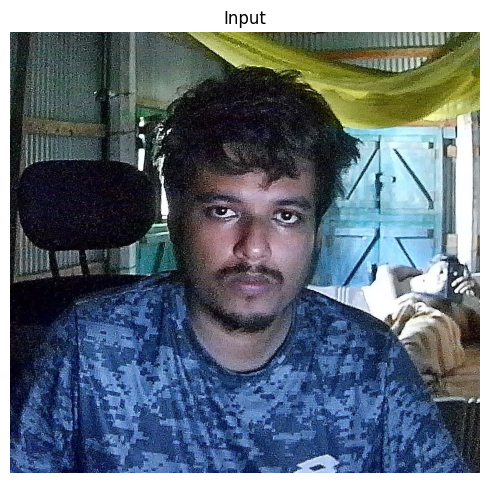

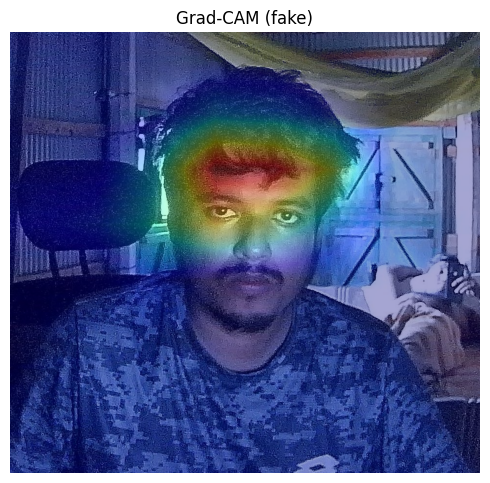

{'p_real': 0.9727707505226135, 'p_fake': 0.027229249477386475, 'label': 1, 'input_png': 'C:\\Users\\Shohan\\Desktop\\DeepFakeImg\\DeepFakeDensenet\\experiments\\densenet121_builder_20250822_200530\\checkpoints\\densenet121_builder_20250822_200530\\explainability\\input.png', 'gradcam_png': 'C:\\Users\\Shohan\\Desktop\\DeepFakeImg\\DeepFakeDensenet\\experiments\\densenet121_builder_20250822_200530\\checkpoints\\densenet121_builder_20250822_200530\\explainability\\gradcam_fake.png', 'occlusion_png': None}


In [19]:
# === XAI: Grad-CAM (+ optional Occlusion) for DenseNet-121 ===
from pathlib import Path
import os, json, numpy as np, torch, torch.nn as nn
from torchvision import models, transforms
from torchvision.transforms import Normalize
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

# ------------------------- Config -------------------------
CKPT_DIR  = Path(r"C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530")
FULL_PATH = CKPT_DIR / "full_model.pth"
META_PATH = CKPT_DIR / "model_meta.json"
assert FULL_PATH.exists() and META_PATH.exists(), "Missing full_model.pth or model_meta.json"

# Calibration / threshold
T_CAL = 0.556238
THR   = None  # e.g. 0.9998254179954529, or None to use 0.5

# ---------------------- Class mapping ----------------------
def load_class_maps():
    candidates = [
        CKPT_DIR.parent.parent / "class_names.json",
        CKPT_DIR / "class_names.json",
        Path("class_names.json"),
    ]
    for p in candidates:
        if p.exists():
            with open(p, "r") as f:
                m = json.load(f)  # {"fake":0,"real":1}
            inv = {int(v): str(k) for k, v in m.items()}
            return m, inv
    m = {"fake": 0, "real": 1}
    inv = {0: "fake", 1: "real"}
    return m, inv

CLS_MAP, INV_CLS_MAP = load_class_maps()

# ---------------------- Transforms -------------------------
def default_val_transform(img_size=256):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])

def summarize_transform(transform_obj):
    applied = transform_obj is not None
    has_norm = False; norm_stats=None
    if applied and hasattr(transform_obj, "transforms"):
        for t in transform_obj.transforms:
            if isinstance(t, Normalize):
                has_norm=True
                norm_stats=(tuple(getattr(t,"mean",[])), tuple(getattr(t,"std",[])))
                break
    print(f"[Preprocessing] Provided transform: {bool(applied)}")
    print(f"[Preprocessing] Normalize found: {has_norm}" + (f"  mean={norm_stats[0]} std={norm_stats[1]}" if has_norm else ""))

# ---------------------- Model loader -----------------------
def load_full_model(full_path: Path, meta_path: Path, device=None):
    sd = torch.load(str(full_path), map_location="cpu")
    with open(meta_path, "r") as f:
        meta = json.load(f)
    assert meta["arch"] == "densenet121", f"arch={meta['arch']} unsupported"

    m = models.densenet121(weights=None)
    # rebuild classifier exactly as saved
    mods=[]
    for it in meta.get("classifier_spec", []):
        t=it["type"]
        if t=="Linear": mods.append(nn.Linear(it["in"], it["out"]))
        elif t=="BatchNorm1d": mods.append(nn.BatchNorm1d(it["num_features"]))
        elif t=="LayerNorm": mods.append(nn.LayerNorm(it["normalized_shape"]))
        elif t=="Dropout": mods.append(nn.Dropout(p=it.get("p", 0.5)))
        elif t=="ReLU": mods.append(nn.ReLU(inplace=False))
        else: mods.append(nn.Identity())
    if mods:
        m.classifier = nn.Sequential(*mods)

    m.load_state_dict(sd, strict=True)
    dev = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    m.to(dev).eval()
    return m, dev

# ---------------- Find last conv2d layer -------------------
def get_last_conv(module: nn.Module):
    last = None
    for _, sub in module.named_modules():
        if isinstance(sub, nn.Conv2d):
            last = sub
    if last is None:
        raise RuntimeError("No Conv2d layer found for Grad-CAM.")
    return last

# ------------------------ Grad-CAM -------------------------
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.h1 = target_layer.register_forward_hook(self._save_activation)
        self.h2 = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, m, i, o):
        self.activations = o.detach()

    def _save_gradient(self, m, gi, go):
        self.gradients = go[0].detach()

    def remove(self):
        self.h1.remove(); self.h2.remove()

    def __call__(self, score: torch.Tensor):
        self.model.zero_grad(set_to_none=True)
        score.backward(retain_graph=True)
        A = self.activations
        G = self.gradients
        if A is None or G is None:
            raise RuntimeError("Grad-CAM hooks did not capture activations/gradients. Ensure hooks were registered BEFORE forward.")
        weights = G.mean(dim=(2,3), keepdim=True)     # [N,C,1,1]
        cam = (weights * A).sum(dim=1)                # [N,H,W]
        cam = F.relu(cam)
        # normalize per-sample to [0,1]
        cam_min = cam.view(cam.size(0), -1).min(dim=1)[0].view(-1,1,1)
        cam_max = cam.view(cam.size(0), -1).max(dim=1)[0].view(-1,1,1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-12)
        return cam

# --------------------- Helpers/overlay ---------------------
def overlay_cam_on_image(img_pil, cam_2d, alpha=0.35):
    cam_resized = Image.fromarray((cam_2d*255).astype(np.uint8)).resize(img_pil.size, resample=Image.BILINEAR)
    cmap = plt.cm.jet(np.array(cam_resized)/255.0)    # RGBA [H,W,4]
    cam_rgb = (cmap[:,:,:3]*255).astype(np.uint8)
    cam_color = Image.fromarray(cam_rgb, mode="RGB")
    blended = Image.blend(img_pil, cam_color, alpha=alpha)
    return blended

def forward_logits(model, x):
    out = model(x)
    if out.ndim==2 and out.shape[1]==2:
        logits2 = out
        logit1  = (out[:,1] - out[:,0]).view(-1)
        return logits2, logit1
    return None, out.view(-1)

# ------------------ Occlusion Sensitivity ------------------
def occlusion_map(model, x, patch=32, stride=16, target_class=1):
    model.eval()
    with torch.no_grad():
        _, logit1 = forward_logits(model, x)
        base_prob1 = torch.sigmoid(logit1 / T_CAL).item()

    _, _, H, W = x.shape
    heat = np.zeros((H, W), dtype=np.float32)

    for y in tqdm(range(0, H, stride), desc="Occlusion"):
        for x0 in range(0, W, stride):
            x_occ = x.clone()
            y1 = min(y+patch, H); x1 = min(x0+patch, W)
            x_occ[:,:,y:y1,x0:x1] = 0.0
            with torch.no_grad():
                _, logit1_occ = forward_logits(model, x_occ)
                prob1 = torch.sigmoid(logit1_occ / T_CAL).item()
            delta = base_prob1 - prob1
            if target_class == 0:
                delta = -delta
            heat[y:y1, x0:x1] += delta

    m, M = heat.min(), heat.max()
    heat = (heat - m) / (M - m + 1e-12)
    return heat

# -------------------- Explain one image --------------------
@torch.inference_mode(False)  # need grads for CAM
def explain_image_path(img_path, out_dir=None, target_class_name="fake",
                       use_occlusion=False, transform=None, img_size=256):
    # transform
    if transform is None:
        try:
            transform = val_test_transform  # if notebook defines it
        except NameError:
            transform = default_val_transform(img_size)

    summarize_transform(transform)
    target_class = CLS_MAP.get(target_class_name, 0)

    model, device = load_full_model(FULL_PATH, META_PATH)
    model.eval()

    # input
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img_disp = img.copy()  # for overlays
    x = transform(img).unsqueeze(0).to(device)

    # register hooks BEFORE forward
    last_conv = get_last_conv(model.features)
    cam_engine = GradCAM(model, last_conv)

    # forward for logits and prob
    _, logit1 = forward_logits(model, x)
    prob_real = torch.sigmoid(logit1 / T_CAL).item()
    prob_fake = 1.0 - prob_real

    # decision
    if THR is not None:
        label = 1 if prob_real >= THR else 0
    else:
        label = 1 if prob_real >= 0.5 else 0

    print(f"[Pred] p(real)={prob_real:.6f} p(fake)={prob_fake:.6f} -> label={INV_CLS_MAP.get(label,str(label))}")

    # scalar score for desired class
    score = logit1 if target_class == 1 else -logit1

    # compute CAM
    cam = cam_engine(score)           # [1,Hc,Wc]
    cam_engine.remove()
    cam_2d = cam[0].detach().cpu().numpy()

    # overlays
    overlay = overlay_cam_on_image(img_disp, cam_2d, alpha=0.35)

    # optional occlusion
    occ_overlay = None; occ_path = None
    if use_occlusion:
        with torch.no_grad():
            occ = occlusion_map(model, x.detach(), patch=32, stride=16, target_class=target_class)
        occ_overlay = overlay_cam_on_image(img_disp, occ, alpha=0.35)

    # outputs
    out_dir = Path(out_dir) if out_dir is not None else (CKPT_DIR / "explainability")
    out_dir.mkdir(parents=True, exist_ok=True)
    in_path  = out_dir / "input.png"
    gc_path  = out_dir / f"gradcam_{target_class_name}.png"
    img_disp.save(in_path)
    overlay.save(gc_path)
    print("Saved:", in_path)
    print("Saved:", gc_path)

    if occ_overlay is not None:
        occ_path = out_dir / f"occlusion_{target_class_name}.png"
        occ_overlay.save(occ_path)
        print("Saved:", occ_path)

    # inline previews (one chart per figure)
    plt.figure(figsize=(5,5)); plt.imshow(img_disp); plt.axis('off'); plt.title("Input"); plt.tight_layout(); plt.show()
    plt.figure(figsize=(5,5)); plt.imshow(overlay);  plt.axis('off'); plt.title(f"Grad-CAM ({target_class_name})"); plt.tight_layout(); plt.show()
    if occ_overlay is not None:
        plt.figure(figsize=(5,5)); plt.imshow(occ_overlay); plt.axis('off'); plt.title(f"Occlusion ({target_class_name})"); plt.tight_layout(); plt.show()

    return {
        "p_real": prob_real,
        "p_fake": prob_fake,
        "label": label,
        "input_png": str(in_path),
        "gradcam_png": str(gc_path),
        "occlusion_png": (str(occ_path) if occ_overlay is not None else None)
    }

# --------------------- Example usage -----------------------
# If your notebook already has val_test_transform, it will be used.
# Otherwise default_val_transform(256) is applied.
res = explain_image_path(
    img_path=r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\SB.jpg",
    target_class_name="fake",
    use_occlusion=False,
    transform=None  # keep None to auto-pick
)
print(res)


# 🔎 XAI: LIME (Local Interpretable Model-Agnostic Explanations) for DenseNet-121
This section generates pixel-level explanations for Deepfake vs Real classification using the trained DenseNet-121 model.  
LIME perturbs the input image and trains a local surrogate model to highlight regions most influential for the prediction.  
We will visualize the superpixel importance for both classes to compare model reasoning.


[Preprocessing] Provided transform: True
[Preprocessing] Normalize found: True  mean=(0.485, 0.456, 0.406) std=(0.229, 0.224, 0.225)


100%|██████████| 2000/2000 [21:10<00:00,  1.57it/s]


[Pred] p(real)=0.879640 p(fake)=0.120360 -> label=real


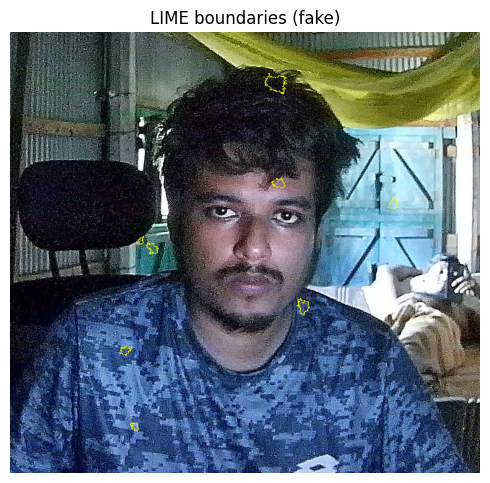

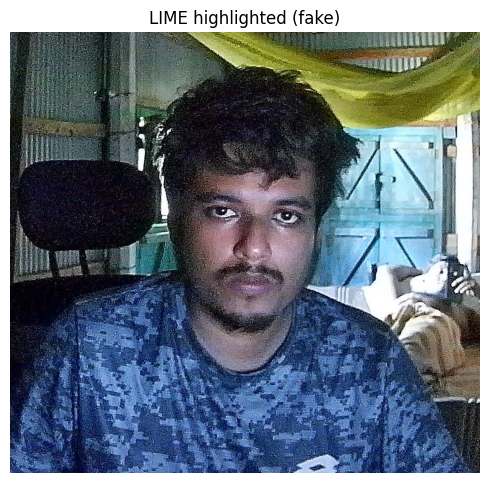

Saved: C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530\explainability_lime\input.png
Saved: C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530\explainability_lime\lime_mask_fake.png
Saved: C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530\explainability_lime\lime_heat_fake.png
Saved: C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530\explainability_lime\lime_weights_fake.json
{'input_png': 'C:\\Users\\Shohan\\Desktop\\DeepFakeImg\\DeepFakeDensenet\\experiments\\densenet121_builder_20250822_200530\\checkpoints\\densenet121_builder_20250822_200530\\explainability_lime\\input.png', 'lime_mask_png': '

In [20]:
# === XAI: LIME for DenseNet-121 (image) ===
from pathlib import Path
import os, json, numpy as np, torch, torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.transforms import Normalize
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# LIME + segmentation
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import slic, quickshift, mark_boundaries

# ------------------------- Config -------------------------
CKPT_DIR  = Path(r"C:\Users\Shohan\Desktop\DeepFakeImg\DeepFakeDensenet\experiments\densenet121_builder_20250822_200530\checkpoints\densenet121_builder_20250822_200530")
FULL_PATH = CKPT_DIR / "full_model.pth"
META_PATH = CKPT_DIR / "model_meta.json"
assert FULL_PATH.exists() and META_PATH.exists(), "Missing full_model.pth or model_meta.json"

# Calibration / threshold used by your classifier elsewhere
T_CAL = 0.556238
THR   = None  # decision threshold for 'real' if you need it; not used by LIME directly

# ---------------------- Class mapping ----------------------
def load_class_maps():
    candidates = [
        CKPT_DIR.parent.parent / "class_names.json",
        CKPT_DIR / "class_names.json",
        Path("class_names.json"),
    ]
    for p in candidates:
        if p.exists():
            with open(p, "r") as f:
                m = json.load(f)  # {"fake":0,"real":1}
            inv = {int(v): str(k) for k, v in m.items()}
            return m, inv
    m = {"fake": 0, "real": 1}
    inv = {0: "fake", 1: "real"}
    return m, inv

CLS_MAP, INV_CLS_MAP = load_class_maps()

# ---------------------- Transforms -------------------------
def default_val_transform(img_size=256):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])

# inverse normalization for visualization if needed
def inv_normalize_tensor(x, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    m = torch.tensor(mean, device=x.device).view(1,-1,1,1)
    s = torch.tensor(std,  device=x.device).view(1,-1,1,1)
    return x * s + m

def summarize_transform(transform_obj):
    applied = transform_obj is not None
    has_norm = False; norm_stats=None
    if applied and hasattr(transform_obj, "transforms"):
        for t in transform_obj.transforms:
            if isinstance(t, Normalize):
                has_norm=True; norm_stats=(tuple(getattr(t,"mean",[])), tuple(getattr(t,"std",[]))); break
    print(f"[Preprocessing] Provided transform: {bool(applied)}")
    print(f"[Preprocessing] Normalize found: {has_norm}" + (f"  mean={norm_stats[0]} std={norm_stats[1]}" if has_norm else ""))

# ---------------------- Model loader -----------------------
def load_full_model(full_path: Path, meta_path: Path, device=None):
    sd = torch.load(str(full_path), map_location="cpu")
    with open(meta_path, "r") as f:
        meta = json.load(f)
    assert meta["arch"] == "densenet121", f"arch={meta['arch']} unsupported"

    m = models.densenet121(weights=None)
    mods=[]
    for it in meta.get("classifier_spec", []):
        t=it["type"]
        if t=="Linear": mods.append(nn.Linear(it["in"], it["out"]))
        elif t=="BatchNorm1d": mods.append(nn.BatchNorm1d(it["num_features"]))
        elif t=="LayerNorm": mods.append(nn.LayerNorm(it["normalized_shape"]))
        elif t=="Dropout": mods.append(nn.Dropout(p=it.get("p", 0.5)))
        elif t=="ReLU": mods.append(nn.ReLU(inplace=False))
        else: mods.append(nn.Identity())
    if mods:
        m.classifier = nn.Sequential(*mods)

    m.load_state_dict(sd, strict=True)
    dev = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    m.to(dev).eval()
    return m, dev

# --------------------- Forward helpers ---------------------
def forward_logits(model, x):
    out = model(x)
    if out.ndim==2 and out.shape[1]==2:
        logits2 = out
        logit1  = (out[:,1] - out[:,0]).view(-1)  # margin for class-1
        return logits2, logit1
    return None, out.view(-1)

def logits_to_probs(logits2, logit1):
    if logits2 is not None:
        probs = F.softmax(logits2, dim=1)  # [N,2]
        return probs
    # one-logit: class-1 vs class-0 using calibrated sigmoid
    p1 = torch.sigmoid(logit1 / T_CAL).unsqueeze(1)
    p0 = 1.0 - p1
    return torch.cat([p0, p1], dim=1)  # [N,2]

# ------------------ LIME prediction wrapper ----------------
class LimePredictor:
    """
    Wraps your model for LIME. Accepts a numpy array (N,H,W,3) in [0,255] or [0,1],
    applies your transform, and returns probs Nx2 matching class index order in CLS_MAP.
    """
    def __init__(self, model, device, transform):
        self.model = model
        self.device = device
        self.transform = transform

    def __call__(self, batch_np):
        self.model.eval()
        imgs = []
        for arr in batch_np:
            # ensure uint8 -> PIL
            if arr.dtype != np.uint8:
                arr_255 = np.clip(arr*255.0, 0, 255).astype(np.uint8)
            else:
                arr_255 = arr
            pil = Image.fromarray(arr_255).convert("RGB")
            t = self.transform(pil)
            imgs.append(t)
        x = torch.stack(imgs, dim=0).to(self.device)
        with torch.no_grad():
            logits2, logit1 = forward_logits(self.model, x)
            probs = logits_to_probs(logits2, logit1)  # [N,2]
        return probs.detach().cpu().numpy()  # LIME expects numpy

# ------------------ LIME explanation function ---------------
def lime_explain_image_path(img_path,
                            out_dir=None,
                            target_class_name="fake",
                            transform=None,
                            img_size=256,
                            num_samples=2000,
                            segmentation="quickshift",
                            top_labels=2,
                            positive_only=True,
                            num_features=10,
                            hide_color=0,
                            random_state=123):
    """
    Generates LIME explanation. Saves:
      - input.png
      - lime_mask_<cls>.png (mask overlay with boundaries)
      - lime_heat_<cls>.png (positive superpixels highlighted)
    Returns dict with paths and predicted probs.
    """
    # transform
    if transform is None:
        try:
            transform = val_test_transform
        except NameError:
            transform = default_val_transform(img_size)
    summarize_transform(transform)

    # load model
    model, device = load_full_model(FULL_PATH, META_PATH)

    # IO
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img_np = np.array(img)

    # predictor
    predictor = LimePredictor(model, device, transform)

    # run explainer
    explainer = LimeImageExplainer(random_state=random_state)

    # segmentation function
    if segmentation == "slic":
        seg_fn = lambda im: slic(im, n_segments=200, compactness=10, sigma=1, start_label=0)
    else:
        seg_fn = lambda im: quickshift(im, kernel_size=3, max_dist=6, ratio=0.5)

    explanation = explainer.explain_instance(
        image=img_np,
        classifier_fn=predictor,
        top_labels=top_labels,
        hide_color=hide_color,
        num_samples=num_samples,
        segmentation_fn=seg_fn
    )

    # model prediction for reporting
    probs = predictor(np.expand_dims(img_np, 0))[0]  # [2]
    idx_fake = CLS_MAP["fake"]
    idx_real = CLS_MAP["real"]
    p_fake = float(probs[idx_fake])
    p_real = float(probs[idx_real])
    pred_idx = int(np.argmax(probs))
    pred_name = INV_CLS_MAP.get(pred_idx, str(pred_idx))
    print(f"[Pred] p(real)={p_real:.6f} p(fake)={p_fake:.6f} -> label={pred_name}")

    # choose target class
    target_idx = CLS_MAP.get(target_class_name, 0)

    # get image and mask for target class
    temp, mask = explanation.get_image_and_mask(
        label=target_idx,
        positive_only=positive_only,
        num_features=num_features,
        hide_rest=False
    )  # temp is RGB with highlights

    # prepare outputs
    out_dir = Path(out_dir) if out_dir is not None else (CKPT_DIR / "explainability_lime")
    out_dir.mkdir(parents=True, exist_ok=True)
    in_path   = out_dir / "input.png"
    mask_path = out_dir / f"lime_mask_{target_class_name}.png"
    heat_path = out_dir / f"lime_heat_{target_class_name}.png"

    Image.fromarray(img_np).save(in_path)

    # Figure 1: boundaries overlay on original
    fig1 = plt.figure(figsize=(5,5))
    plt.imshow(mark_boundaries(img_np/255.0, mask))
    plt.axis('off'); plt.title(f"LIME boundaries ({target_class_name})")
    plt.tight_layout(); fig1.savefig(mask_path, dpi=200)
    plt.show()

    # Figure 2: LIME highlighted regions returned by get_image_and_mask
    fig2 = plt.figure(figsize=(5,5))
    plt.imshow(temp)
    plt.axis('off'); plt.title(f"LIME highlighted ({target_class_name})")
    plt.tight_layout(); fig2.savefig(heat_path, dpi=200)
    plt.show()

    print("Saved:", in_path)
    print("Saved:", mask_path)
    print("Saved:", heat_path)

    # also dump the local explanation weights
    weights = dict(explanation.local_exp.get(target_idx, []))  # {superpixel_id: weight}
    weights_path = out_dir / f"lime_weights_{target_class_name}.json"
    with open(weights_path, "w") as f:
        json.dump({str(k): float(v) for k, v in weights.items()}, f, indent=2)
    print("Saved:", weights_path)

    return {
        "input_png": str(in_path),
        "lime_mask_png": str(mask_path),
        "lime_highlight_png": str(heat_path),
        "lime_weights_json": str(weights_path),
        "probs": {"fake": p_fake, "real": p_real},
        "pred_label": pred_name
    }

# --------------------- Example usage -----------------------
# Set transform=None to auto-pick your notebook's val_test_transform or a safe default.
lime_res = lime_explain_image_path(
    img_path=r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\SB.jpg",
    target_class_name="fake",
    transform=None,
    num_samples=2000,          # increase for more stable explanations
    segmentation="quickshift", # or "slic"
    num_features=10,
    positive_only=True
)
print(lime_res)
